# Accessing Databases using Python
- SQLite version

| Topic | Description | Example |
|-------|-------|-------|
| **connect()**   | 새로 db를 생성하거나 열어서 sqlite3와 연결되도록 함  | import sqlite3 <br>con = sqlite3.connect("INSTRUCTOR.db") |
| **cursor()**   |  sql 쿼리를 실행하고 결과를 가져오는 역 | cursor_obj = con.cursor() |
| **execute()**   | SQLight 라이브러리 안의 execute함수는 sql 명령을 가능하게 함  | cursor_obj.execute('''insert into INSTRUCTOR values (1, 'Rav', 'Ahuja', 'TORONTO', 'CA')''') |
| **fetchall()**   | 쿼리의 실행결과에서 모든 행을 가져옴  | statement = '''SELECT * FROM INSTRUCTOR'''<br>cursor_obj.execute(statement)<br>output_all = cursor_obj.fetchall()<br>for row_all in output_all:<br>print(row_all) |
| **fetchmany()**   |  충분한 수의 행을 지정하여 가져옴 | statement = '''SELECT * FROM INSTRUCTOR'''<br>cursor_obj.execute(statement)<br>output_many = cursor_obj.fetchmany(2)<br>for row_many in output_many:<br>print(row_many) |
| **read_sql_query()**   | 판다스 라이브러리에서 제공하는 것으로 sql 쿼리를 실행하고 결과를 판다스 df로 리턴함  | df = pd.read_sql_query("select * from instructor;", conn) |
| **close()**   | MySQL데이터베이스와의 연결 해제  | con.close() |
| **barplot()**   |  seaborn 라이브러리에서 제공 | import seaborn<br>seaborn.barplot(x='Test_Score',y='Frequency', data=dataframe) |
| **read_csv()**   | 판다스 라이브러리에서 제공. csv파일을 읽어서 판다스 df형식으로 저장  | import pandas<br>df = pandas.read_csv('https://data.cityofchicago.org/resource/jcxq-k9xf.csv') |
| **to_sql()**   | 판다스 라이브러리에서 제공. df의 내용을 sql 데이터베이스에 저장  | import pandas<br>df = pandas.read_csv('https://data.cityofchicago.org/resource/jcxq-k9xf.csv')<br>df.to_sql("chicago_socioeconomic_data", con, if_exists='replace', index=False,method="multi") |
| **read_sql()**   | 판다스 라이브러리에서 제공. sql 데이터베이스의 내용을 df에 저장  | selectQuery = "select * from INSTRUCTOR"<br>df = pandas.read_sql(selectQuery, conn) |


## **Section 1 : Create & Access SQLite database using Python**

In [1]:
import sqlite3  # SQL db engine

# sqlite에 연결, conn은 connection object
conn = sqlite3.connect('INSTRUCTOR.db')

# cursor object : 데이터를 가져오는 메서드를 호출할 수 있게 함
cursor_obj = conn.cursor()

#### `01` DB 생성 및 데이터 삽입

In [2]:
# Drop the table if already exists.
cursor_obj.execute("DROP TABLE IF EXISTS INSTRUCTOR")

# Creating table
table = """ create table IF NOT EXISTS INSTRUCTOR(ID INTEGER PRIMARY KEY NOT NULL, FNAME VARCHAR(20), LNAME VARCHAR(20), CITY VARCHAR(20), CCODE CHAR(2));"""
 
cursor_obj.execute(table)
 
print("Table is Ready")

# Insert data
cursor_obj.execute('''insert into INSTRUCTOR values (1, 'Rav', 'Ahuja', 'TORONTO', 'CA')''')
cursor_obj.execute('''insert into INSTRUCTOR values (2, 'Raul', 'Chong', 'Markham', 'CA'), (3, 'Hima', 'Vasudevan', 'Chicago', 'US')''')

Table is Ready


#### `02` 데이터 쿼리 실행

In [3]:
statement = '''SELECT * FROM INSTRUCTOR'''
cursor_obj.execute(statement)

print("All the data")
output_all = cursor_obj.fetchall()  # fetchall 사용
for row_all in output_all:
    print(row_all)

All the data
(1, 'Rav', 'Ahuja', 'TORONTO', 'CA')
(2, 'Raul', 'Chong', 'Markham', 'CA')
(3, 'Hima', 'Vasudevan', 'Chicago', 'US')


In [4]:
statement = '''SELECT * FROM INSTRUCTOR'''
cursor_obj.execute(statement)

print("All the data")
# fetch few rows
output_many = cursor_obj.fetchmany(2)  # fetchmany 사용
for fetch in output_many:
    print(fetch)

All the data
(1, 'Rav', 'Ahuja', 'TORONTO', 'CA')
(2, 'Raul', 'Chong', 'Markham', 'CA')


In [5]:
statement = '''SELECT FNAME FROM INSTRUCTOR'''
cursor_obj.execute(statement)

print("All the data")
output_column = cursor_obj.fetchall()
for fetch in output_column:
    print(fetch)

All the data
('Rav',)
('Raul',)
('Hima',)


In [6]:
# 쿼리 업데이트
query_update = '''update INSTRUCTOR set CITY = 'MOOSETOWN' where FNAME = "Rav"'''
cursor_obj.execute(query_update)

In [7]:
statement = '''SELECT * FROM INSTRUCTOR'''
cursor_obj.execute(statement)

print("All the data")
output1 = cursor_obj.fetchmany(2)
for row in output1:
    print(row)

All the data
(1, 'Rav', 'Ahuja', 'MOOSETOWN', 'CA')
(2, 'Raul', 'Chong', 'Markham', 'CA')


#### `03` pandas 데이터 프레임으로 변환

In [8]:
!pip install pandas
import pandas as pd

In [9]:
#retrieve the query results into a pandas dataframe
df = pd.read_sql_query("select * from instructor;", conn)

#print the dataframe
df

,ID,FNAME,LNAME,CITY,CCODE
0,1,Rav,Ahuja,MOOSETOWN,CA
1,2,Raul,Chong,Markham,CA
2,3,Hima,Vasudevan,Chicago,US


In [10]:
#print just the LNAME for first row in the pandas data frame
df.LNAME[0]

'Ahuja'

In [11]:
df.shape

(3, 5)

#### `04` 연결 끊기

In [12]:
# Close the connection
conn.close()

## **Section 2 : Accessing Databases with SQL Magic**

#### `00` SQL 연결

In [13]:
!pip install ipython-sql

In [14]:
%load_ext sql  
# ipython-sql extension 로드

In [15]:
import csv, sqlite3

con = sqlite3.connect("SQLiteMagic.db")  # SQLiteMagic.db라는 이름의 데이터베이스 파일에 연결 or 생성
cur = con.cursor()  # 커서 객체 생성

In [16]:
# sqllite를 이용해서 magic sql에 연결
%sql sqlite:///SQLiteMagic.db  # IPython 매직 명령어

(sqlite3.OperationalError) unrecognized token: "#"
[SQL: # IPython 매직 명령어]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


#### `01` 테이블 생성

**%%sql** : 셀 상단에 사용하여 전체 셀이 SQL로 취급되도록 선언

In [17]:
%%sql

CREATE TABLE INTERNATIONAL_STUDENT_TEST_SCORES (
	country VARCHAR(50),
	first_name VARCHAR(50),
	last_name VARCHAR(50),
	test_score INT
);
INSERT INTO INTERNATIONAL_STUDENT_TEST_SCORES (country, first_name, last_name, test_score)
VALUES
('United States', 'Marshall', 'Bernadot', 54),
('Ghana', 'Celinda', 'Malkin', 51),
('Ukraine', 'Guillermo', 'Furze', 53),
('Greece', 'Aharon', 'Tunnow', 48),
('Russia', 'Bail', 'Goodwin', 46),
('Poland', 'Cole', 'Winteringham', 49),
('Sweden', 'Emlyn', 'Erricker', 55),
('Russia', 'Cathee', 'Sivewright', 49),
('China', 'Barny', 'Ingerson', 57),
('Uganda', 'Sharla', 'Papaccio', 55),
('China', 'Stella', 'Youens', 51),
('Poland', 'Julio', 'Buesden', 48),
('United States', 'Tiffie', 'Cosely', 58),
('Poland', 'Auroora', 'Stiffell', 45),
('China', 'Clarita', 'Huet', 52),
('Poland', 'Shannon', 'Goulden', 45),
('Philippines', 'Emylee', 'Privost', 50),
('France', 'Madelina', 'Burk', 49),
('China', 'Saunderson', 'Root', 58),
('Indonesia', 'Bo', 'Waring', 55),
('China', 'Hollis', 'Domotor', 45),
('Russia', 'Robbie', 'Collip', 46),
('Philippines', 'Davon', 'Donisi', 46),
('China', 'Cristabel', 'Radeliffe', 48),
('China', 'Wallis', 'Bartleet', 58),
('Moldova', 'Arleen', 'Stailey', 38),
('Ireland', 'Mendel', 'Grumble', 58),
('China', 'Sallyann', 'Exley', 51),
('Mexico', 'Kain', 'Swaite', 46),
('Indonesia', 'Alonso', 'Bulteel', 45),
('Armenia', 'Anatol', 'Tankus', 51),
('Indonesia', 'Coralyn', 'Dawkins', 48),
('China', 'Deanne', 'Edwinson', 45),
('China', 'Georgiana', 'Epple', 51),
('Portugal', 'Bartlet', 'Breese', 56),
('Azerbaijan', 'Idalina', 'Lukash', 50),
('France', 'Livvie', 'Flory', 54),
('Malaysia', 'Nonie', 'Borit', 48),
('Indonesia', 'Clio', 'Mugg', 47),
('Brazil', 'Westley', 'Measor', 48),
('Philippines', 'Katrinka', 'Sibbert', 51),
('Poland', 'Valentia', 'Mounch', 50),
('Norway', 'Sheilah', 'Hedditch', 53),
('Papua New Guinea', 'Itch', 'Jubb', 50),
('Latvia', 'Stesha', 'Garnson', 53),
('Canada', 'Cristionna', 'Wadmore', 46),
('China', 'Lianna', 'Gatward', 43),
('Guatemala', 'Tanney', 'Vials', 48),
('France', 'Alma', 'Zavittieri', 44),
('China', 'Alvira', 'Tamas', 50),
('United States', 'Shanon', 'Peres', 45),
('Sweden', 'Maisey', 'Lynas', 53),
('Indonesia', 'Kip', 'Hothersall', 46),
('China', 'Cash', 'Landis', 48),
('Panama', 'Kennith', 'Digance', 45),
('China', 'Ulberto', 'Riggeard', 48),
('Switzerland', 'Judy', 'Gilligan', 49),
('Philippines', 'Tod', 'Trevaskus', 52),
('Brazil', 'Herold', 'Heggs', 44),
('Latvia', 'Verney', 'Note', 50),
('Poland', 'Temp', 'Ribey', 50),
('China', 'Conroy', 'Egdal', 48),
('Japan', 'Gabie', 'Alessandone', 47),
('Ukraine', 'Devlen', 'Chaperlin', 54),
('France', 'Babbette', 'Turner', 51),
('Czech Republic', 'Virgil', 'Scotney', 52),
('Tajikistan', 'Zorina', 'Bedow', 49),
('China', 'Aidan', 'Rudeyeard', 50),
('Ireland', 'Saunder', 'MacLice', 48),
('France', 'Waly', 'Brunstan', 53),
('China', 'Gisele', 'Enns', 52),
('Peru', 'Mina', 'Winchester', 48),
('Japan', 'Torie', 'MacShirrie', 50),
('Russia', 'Benjamen', 'Kenford', 51),
('China', 'Etan', 'Burn', 53),
('Russia', 'Merralee', 'Chaperlin', 38),
('Indonesia', 'Lanny', 'Malam', 49),
('Canada', 'Wilhelm', 'Deeprose', 54),
('Czech Republic', 'Lari', 'Hillhouse', 48),
('China', 'Ossie', 'Woodley', 52),
('Macedonia', 'April', 'Tyer', 50),
('Vietnam', 'Madelon', 'Dansey', 53),
('Ukraine', 'Korella', 'McNamee', 52),
('Jamaica', 'Linnea', 'Cannam', 43),
('China', 'Mart', 'Coling', 52),
('Indonesia', 'Marna', 'Causbey', 47),
('China', 'Berni', 'Daintier', 55),
('Poland', 'Cynthia', 'Hassell', 49),
('Canada', 'Carma', 'Schule', 49),
('Indonesia', 'Malia', 'Blight', 48),
('China', 'Paulo', 'Seivertsen', 47),
('Niger', 'Kaylee', 'Hearley', 54),
('Japan', 'Maure', 'Jandak', 46),
('Argentina', 'Foss', 'Feavers', 45),
('Venezuela', 'Ron', 'Leggitt', 60),
('Russia', 'Flint', 'Gokes', 40),
('China', 'Linet', 'Conelly', 52),
('Philippines', 'Nikolas', 'Birtwell', 57),
('Australia', 'Eduard', 'Leipelt', 53)


 * sqlite:///SQLiteMagic.db
(sqlite3.OperationalError) table INTERNATIONAL_STUDENT_TEST_SCORES already exists
[SQL: CREATE TABLE INTERNATIONAL_STUDENT_TEST_SCORES (
	country VARCHAR(50),
	first_name VARCHAR(50),
	last_name VARCHAR(50),
	test_score INT
);]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


테이블 출력 설정

In [18]:
# Install the 'ipython-sql' and 'prettytable' libraries using pip
!pip install ipython-sql prettytable

# Import the 'prettytable' library, which is used to display data in a formatted table
import prettytable

# Set the default display format for prettytable to 'DEFAULT' (i.e., a simple table format)
prettytable.DEFAULT = 'DEFAULT'

#### `02` sql 문장에 python 변수 활용
- python 변수에는 앞에 ':'를 추가

In [19]:
# python 변수를 활용

country = "Canada"
%sql select * from INTERNATIONAL_STUDENT_TEST_SCORES where country = :country

 * sqlite:///SQLiteMagic.db
Done.


country,first_name,last_name,test_score
Canada,Cristionna,Wadmore,46
Canada,Wilhelm,Deeprose,54
Canada,Carma,Schule,49


In [20]:
# 쿼리 결과를 python 변수에 저장

test_score_distribution = %sql SELECT test_score as "Test_Score", count(*) as "Frequency" from INTERNATIONAL_STUDENT_TEST_SCORES GROUP BY test_score;
test_score_distribution

 * sqlite:///SQLiteMagic.db
Done.


Test_Score,Frequency
38,2
40,1
43,2
44,2
45,8
46,7
47,4
48,14
49,8
50,10


#### `03` 쿼리 결과를 데이터프레임으로 변환

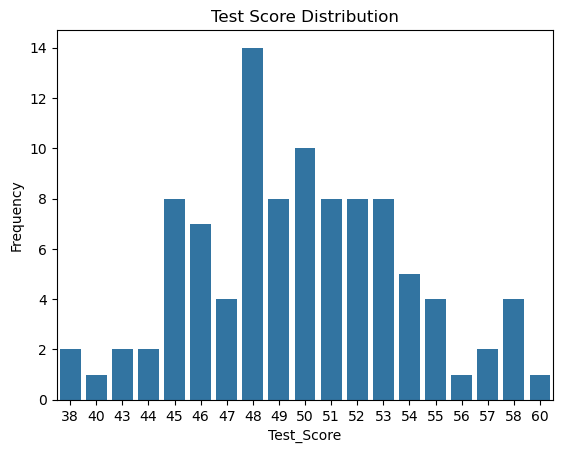

In [22]:
!pip install seaborn
!pip install matplotlib
dataframe = test_score_distribution.DataFrame()

# 그래프를 Jupyter Notebook의 셀 안에 인라인으로 출력되게 설정
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

plot = sns.barplot(x='Test_Score',y='Frequency', data=dataframe)
plt.title("Test Score Distribution")
plt.show()

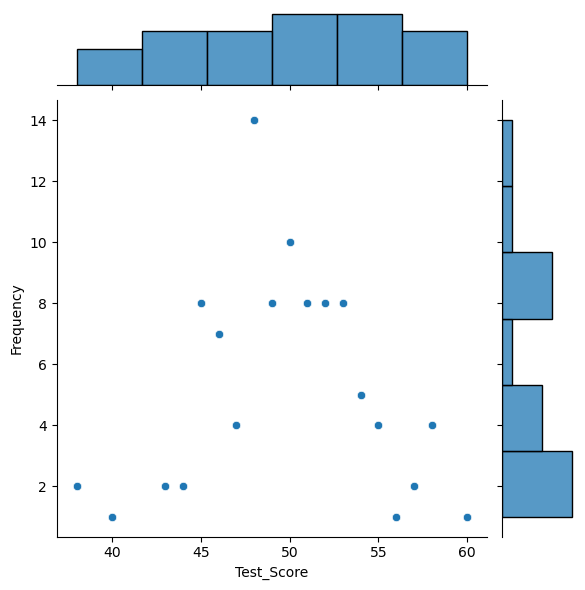

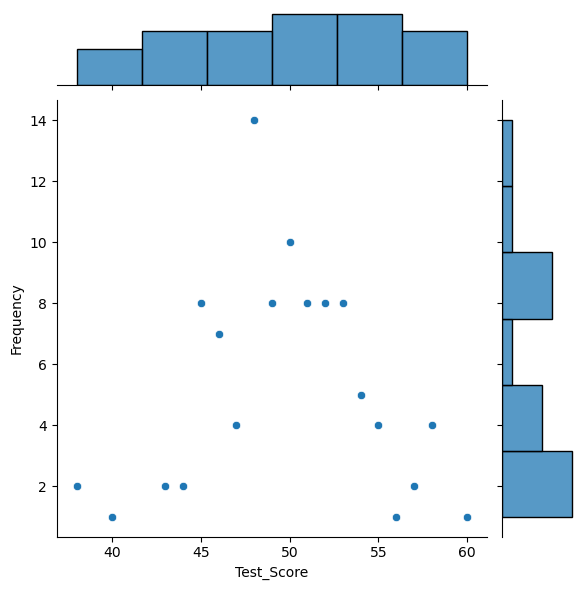

In [29]:
# 상관관계 확인
sns.jointplot(x='Test_Score', y='Frequency', data=dataframe)
plt.show()

## **Section 3 : Retrieving Meta data**

In [34]:
import csv, sqlite3

con = sqlite3.connect("RealWorldData.db")
cur = con.cursor()

!pip install pandas
!pip install ipython-sql prettytable

import prettytable
prettytable.DEFAULT = 'DEFAULT'

!pip install ipython-sql
%load_ext sql

%sql sqlite:///RealWorldData.db

import pandas

df = pandas.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoPublicSchools.csv")
df.to_sql("CHICAGO_PUBLIC_SCHOOLS_DATA", con, if_exists='replace', index=False, method="multi")

  %reload_ext sql



566

In [35]:
# sqlite_master는 메타데이터 테이블로 테이블, 인덱스, 뷰, 트리 등 저장. 그중 테이블만 필터링
# 데이터베이스의 모든 테이블 이름 목록 출력
%sql SELECT name FROM sqlite_master WHERE type='table';

 * sqlite:///RealWorldData.db
   sqlite:///SQLiteMagic.db
Done.


name
CHICAGO_PUBLIC_SCHOOLS_DATA


In [36]:
# PRAGMA_TABLE_INFO()로 해당 테이블의 열 정보를 반환
%sql SELECT count(name) FROM PRAGMA_TABLE_INFO('CHICAGO_PUBLIC_SCHOOLS_DATA');

 * sqlite:///RealWorldData.db
   sqlite:///SQLiteMagic.db
Done.


count(name)
78


In [37]:
# 테이블의 컬럼 이름, 데이터 타입, 타입 문자열 길이 조회
%sql SELECT name, type, length(type) FROM PRAGMA_TABLE_INFO('CHICAGO_PUBLIC_SCHOOLS_DATA');

 * sqlite:///RealWorldData.db
   sqlite:///SQLiteMagic.db
Done.


name,type,length(type)
School_ID,INTEGER,7
NAME_OF_SCHOOL,TEXT,4
"Elementary, Middle, or High School",TEXT,4
Street_Address,TEXT,4
City,TEXT,4
State,TEXT,4
ZIP_Code,INTEGER,7
Phone_Number,TEXT,4
Link,TEXT,4
Network_Manager,TEXT,4


In [38]:
%sql select * from CHICAGO_PUBLIC_SCHOOLS_DATA limit 5;

 * sqlite:///RealWorldData.db
   sqlite:///SQLiteMagic.db
Done.


School_ID,NAME_OF_SCHOOL,"Elementary, Middle, or High School",Street_Address,City,State,ZIP_Code,Phone_Number,Link,Network_Manager,Collaborative_Name,Adequate_Yearly_Progress_Made_,Track_Schedule,CPS_Performance_Policy_Status,CPS_Performance_Policy_Level,HEALTHY_SCHOOL_CERTIFIED,Safety_Icon,SAFETY_SCORE,Family_Involvement_Icon,Family_Involvement_Score,Environment_Icon,Environment_Score,Instruction_Icon,Instruction_Score,Leaders_Icon,Leaders_Score,Teachers_Icon,Teachers_Score,Parent_Engagement_Icon,Parent_Engagement_Score,Parent_Environment_Icon,Parent_Environment_Score,AVERAGE_STUDENT_ATTENDANCE,Rate_of_Misconducts__per_100_students_,Average_Teacher_Attendance,Individualized_Education_Program_Compliance_Rate,Pk_2_Literacy__,Pk_2_Math__,Gr3_5_Grade_Level_Math__,Gr3_5_Grade_Level_Read__,Gr3_5_Keep_Pace_Read__,Gr3_5_Keep_Pace_Math__,Gr6_8_Grade_Level_Math__,Gr6_8_Grade_Level_Read__,Gr6_8_Keep_Pace_Math_,Gr6_8_Keep_Pace_Read__,Gr_8_Explore_Math__,Gr_8_Explore_Read__,ISAT_Exceeding_Math__,ISAT_Exceeding_Reading__,ISAT_Value_Add_Math,ISAT_Value_Add_Read,ISAT_Value_Add_Color_Math,ISAT_Value_Add_Color_Read,Students_Taking__Algebra__,Students_Passing__Algebra__,9th Grade EXPLORE (2009),9th Grade EXPLORE (2010),10th Grade PLAN (2009),10th Grade PLAN (2010),Net_Change_EXPLORE_and_PLAN,11th Grade Average ACT (2011),Net_Change_PLAN_and_ACT,College_Eligibility__,Graduation_Rate__,College_Enrollment_Rate__,COLLEGE_ENROLLMENT,General_Services_Route,Freshman_on_Track_Rate__,X_COORDINATE,Y_COORDINATE,Latitude,Longitude,COMMUNITY_AREA_NUMBER,COMMUNITY_AREA_NAME,Ward,Police_District,Location
610038,Abraham Lincoln Elementary School,ES,615 W Kemper Pl,Chicago,IL,60614,(773) 534-5720,http://schoolreports.cps.edu/SchoolProgressReport_Eng/Spring2011Eng_610038.pdf,Fullerton Elementary Network,NORTH-NORTHWEST SIDE COLLABORATIVE,No,Standard,Not on Probation,Level 1,Yes,Very Strong,99.0,Very Strong,99,Strong,74.0,Strong,66.0,Weak,65,Strong,70,Strong,56,Average,47,96.00%,2.0,96.40%,95.80%,80.1,43.3,89.6,84.9,60.7,62.6,81.9,85.2,52,62.4,66.3,77.9,69.7,64.4,0.2,0.9,Yellow,Green,67.1,54.5,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,813,33,NDA,1171699.458,1915829.428,41.92449696,-87.64452163,7,LINCOLN PARK,43,18,"(41.92449696, -87.64452163)"
610281,Adam Clayton Powell Paideia Community Academy Elementary School,ES,7511 S South Shore Dr,Chicago,IL,60649,(773) 535-6650,http://schoolreports.cps.edu/SchoolProgressReport_Eng/Spring2011Eng_610281.pdf,Skyway Elementary Network,SOUTH SIDE COLLABORATIVE,No,Track_E,Not on Probation,Level 1,No,Average,54.0,Strong,66,Strong,74.0,Very Strong,84.0,Weak,63,Strong,76,Weak,46,Average,50,95.60%,15.7,95.30%,100.00%,62.4,51.7,21.9,15.1,29,42.8,38.5,27.4,44.8,42.7,14.1,34.4,16.8,16.5,0.7,1.4,Green,Green,17.2,27.3,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,521,46,NDA,1196129.985,1856209.466,41.76032435,-87.55673627,43,SOUTH SHORE,7,4,"(41.76032435, -87.55673627)"
610185,Adlai E Stevenson Elementary School,ES,8010 S Kostner Ave,Chicago,IL,60652,(773) 535-2280,http://schoolreports.cps.edu/SchoolProgressReport_Eng/Spring2011Eng_610185.pdf,Midway Elementary Network,SOUTHWEST SIDE COLLABORATIVE,No,Standard,Not on Probation,Level 2,No,Strong,61.0,NDA,NDA,Average,50.0,Weak,36.0,Weak,NDA,NDA,NDA,Average,47,Weak,41,95.70%,2.3,94.70%,98.30%,53.7,26.6,38.3,34.7,43.7,57.3,48.8,39.2,46.8,44,7.5,21.9,18.3,15.5,-0.9,-1.0,Red,Red,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,NDA,1324,44,NDA,1148427.165,1851012.215,41.74711093,-87.73170248,70,ASHBURN,13,8,"(41.74711093, -87.73170248)"
609993,Agustin Lara Elementary Academy,ES,4619 S Wolcott Ave,Chicago,IL,60609,(773) 535-4389,http://schoolreports.cps.edu/SchoolProgressReport_Eng/Spring2011Eng_609993.pdf,Pershing Elementary Network,SOUTHWEST SIDE COLLABORATIVE,No,Track_E,Not on Probation,Level 1,No,Average,56.0,Average,44,Average,45.0,Weak,37.0,Weak,65,Average,48,Average,53,Strong,58,95.50%,10.4,95.80%,100.00%,76.9,NDA,26,24.7,61.8,49.7,39.2,27.2,69.7,60.6,9.1,18.2,11.1,9.6,0.9,2.4,Green,Green,42.9,25,NDA,N

In [39]:
# REPLACE() 함수 사용 : '%'값 제거

%sql SELECT Name_of_School, REPLACE(Average_Student_Attendance, '%', '') \
     from CHICAGO_PUBLIC_SCHOOLS_DATA \
     order by Average_Student_Attendance \
     LIMIT 5

 * sqlite:///RealWorldData.db
   sqlite:///SQLiteMagic.db
Done.


NAME_OF_SCHOOL,"REPLACE(Average_Student_Attendance, '%' , '' )"
Velma F Thomas Early Childhood Center,None
Richard T Crane Technical Preparatory High School,57.90
Barbara Vick Early Childhood & Family Center,60.90
Dyett High School,62.50
Wendell Phillips Academy High School,63.00


In [40]:
%sql select NAME_OF_SCHOOL, SAFETY_SCORE \
    from CHICAGO_PUBLIC_SCHOOLS_DATA \
    where SAFETY_SCORE != 'None' \
    order by SAFETY_SCORE limit 5;

 * sqlite:///RealWorldData.db
   sqlite:///SQLiteMagic.db
Done.


NAME_OF_SCHOOL,SAFETY_SCORE
Edmond Burke Elementary School,1.0
Luke O'Toole Elementary School,5.0
George W Tilton Elementary School,6.0
Foster Park Elementary School,11.0
Emil G Hirsch Metropolitan High School,13.0
